# Notebook 20 — quick cross-stance look (non-serious)

**Purpose.** Three representative stances fit with `pool_3s` + soft reference anchors (three-state leaf + label-tied tree pooling + Beta(50,1) / Beta(1,50) on Human / ELIZA). Not a production comparison; reduced sampling (1000 draws × 4 chains, 500 tune). Exploratory only, to see what the main $P(C=1 \mid \text{data})$ story looks like outside GWT and to audit the (expert × system) PPC.

**Stances.** Global Workspace Theory, Integrated Information Theory, Recurrent Processing Theory (Perceptual) — loosely "the canonical rivals".

In [1]:
import os, sys
sys.path.insert(0, '..')
os.chdir('..')
import arviz as az
import numpy as np
import matplotlib.pyplot as plt

from dcm_model import (EvidenceProcessor, ModelConfig, MultiSystemDataProcessor,
                        MultiSystemModelBuilder, load_data)
from gwt_reference_recovery_analysis import ANCHORED_SYSTEM_CONFIGS
from dcm_ppc import per_expert_system_ppc_multisystem
from tree_propagation_diagnostic import _EXPERT_ANON_MAP

REAL_BY_ANON = {v: k for k, v in _EXPERT_ANON_MAP.items()}
ANON_BY_REAL = dict(_EXPERT_ANON_MAP)

STANCES = [
    ('Global Workspace Theory',                'GWT',    'results/gwt_tree_pooling/three_state_pooled_soft_anchored.nc'),
    ('Integrated Information Theory',          'IIT',    'results/explore_stance/integrated_information_theory.nc'),
    ('Recurrent Processing Theory (Perceptual)', 'RPT-P', 'results/explore_stance/recurrent_processing_theory_perceptual.nc'),
]
SOFT_ANCHORS = {'Human': (50.0, 1.0), 'ELIZA': (1.0, 50.0)}
SYS_VAR = {
    'Human':   'human__{slug}_C',
    'Chicken': 'chicken__{slug}_C',
    'LLMs':    '2024_leading_chat_llms__{slug}_C',
    'ELIZA':   'eliza__{slug}_C',
}

def slug(stance_name):
    # Match dcm_model.sanitize_name
    return stance_name.replace(' ', '_').replace('/', '_').lower()

def load_stance(path, stance_name):
    cfg = ModelConfig(
        INDICATOR_STATE_MODEL='three_state', POOL_BETAS_BY_LABEL=True,
        USE_EXPERT_SHIFTS=False, USE_HIERARCHICAL_EXPERT_CUTPOINTS=False,
        SOFT_REFERENCE_ANCHORS=SOFT_ANCHORS,
    )
    sd = next(s for s in load_data(cfg) if s['name'] == stance_name)
    proc = MultiSystemDataProcessor(cfg); proc.process(sd, [s for s, _ in ANCHORED_SYSTEM_CONFIGS])
    bld = MultiSystemModelBuilder(cfg, EvidenceProcessor(cfg), proc, list(ANCHORED_SYSTEM_CONFIGS))
    bld.build_model(sd)
    return az.from_netcdf(path), bld, proc

fits = {}
for sn, short, path in STANCES:
    if os.path.exists(path):
        idata, bld, proc = load_stance(path, sn)
        fits[short] = dict(stance=sn, idata=idata, bld=bld, proc=proc)
        n_div = int(idata.sample_stats['diverging'].values.sum())
        print(f'{short:<6} loaded from {path} (divergences: {n_div})')
    else:
        print(f'{short:<6} MISSING: {path}')

GWT    loaded from results/gwt_tree_pooling/three_state_pooled_soft_anchored.nc (divergences: 0)


IIT    loaded from results/explore_stance/integrated_information_theory.nc (divergences: 0)


RPT-P  loaded from results/explore_stance/recurrent_processing_theory_perceptual.nc (divergences: 0)


## 1 — System root C posteriors across stances

For each stance, report posterior median and 94% HDI on $C$ per system. The two reference systems (Human, ELIZA) have soft Beta(50,1) / Beta(1,50) priors under this config; Chicken and LLMs have the default Beta(1, 5).

In [2]:
def _sm(x):
    return float(np.median(x)), float(np.percentile(x, 3)), float(np.percentile(x, 97))

def system_C_draws(idata, stance_name, sys_key):
    template = SYS_VAR[sys_key]
    return np.asarray(idata.posterior[template.format(slug=slug(stance_name))].values).reshape(-1)

print(f"{'stance':<6}  {'system':<8}  {'median':>8}  {'94% HDI':>20}")
for short in fits:
    f = fits[short]
    for sys_key in ('Human', 'Chicken', 'LLMs', 'ELIZA'):
        d = system_C_draws(f['idata'], f['stance'], sys_key)
        med, lo, hi = _sm(d)
        print(f"{short:<6}  {sys_key:<8}  {med:>8.4f}  [{lo:.4f}, {hi:.4f}]")
    print()

stance  system      median               94% HDI
GWT     Human       0.9899  [0.9508, 0.9996]
GWT     Chicken     0.3614  [0.0342, 0.7210]
GWT     LLMs        0.1679  [0.0102, 0.5005]
GWT     ELIZA       0.0097  [0.0004, 0.0493]

IIT     Human       0.9922  [0.9608, 0.9997]
IIT     Chicken     0.5637  [0.2418, 0.8083]
IIT     LLMs        0.1828  [0.0126, 0.4905]
IIT     ELIZA       0.0072  [0.0003, 0.0390]

RPT-P   Human       0.9915  [0.9555, 0.9997]
RPT-P   Chicken     0.7381  [0.4860, 0.8926]
RPT-P   LLMs        0.0330  [0.0013, 0.1600]
RPT-P   ELIZA       0.0084  [0.0004, 0.0420]



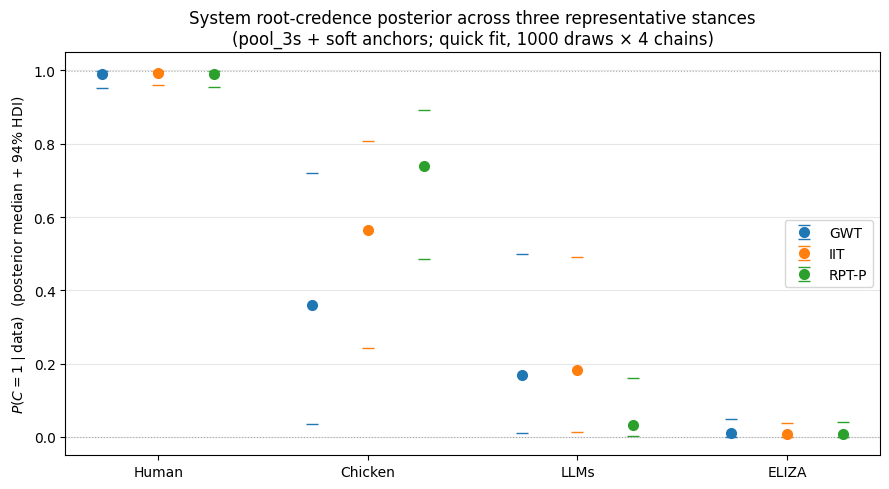

In [3]:
SYS_ORDER = ['Human', 'Chicken', 'LLMs', 'ELIZA']
STANCE_COLORS = {'GWT': '#1f77b4', 'IIT': '#ff7f0e', 'RPT-P': '#2ca02c'}

fig, ax = plt.subplots(figsize=(9, 5))
n_s = len(fits); n_sys = len(SYS_ORDER)
width = 0.8 / n_s
for i, short in enumerate(fits):
    f = fits[short]
    meds = []; lows = []; highs = []
    for sys_key in SYS_ORDER:
        d = system_C_draws(f['idata'], f['stance'], sys_key)
        m, lo, hi = _sm(d)
        meds.append(m); lows.append(m - lo); highs.append(hi - m)
    x = np.arange(n_sys) + (i - (n_s - 1) / 2) * width
    ax.errorbar(x, meds, yerr=[lows, highs], fmt='o', capsize=4,
                color=STANCE_COLORS[short], markersize=7, label=short, linewidth=0)

ax.set_xticks(np.arange(n_sys))
ax.set_xticklabels(SYS_ORDER, fontsize=10)
ax.set_ylabel(r'$P(C=1 \mid \mathrm{data})$  (posterior median + 94% HDI)')
ax.set_ylim(-0.05, 1.05)
ax.axhline(0.999, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
ax.axhline(0.001, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
ax.set_title('System root-credence posterior across three representative stances\n(pool_3s + soft anchors; quick fit, 1000 draws × 4 chains)')
ax.legend(loc='center right', fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('notebooks/figs/nb20_root_C_comparison.png', dpi=140, bbox_inches='tight')
plt.show()

## 2 — Expert × system PPC per stance

Same grid as the Friday brief figure, but reproduced for each of the three stances. Each cell shows the observed rating distribution (blue) and the model's posterior predictive (salmon) with 94% intervals.

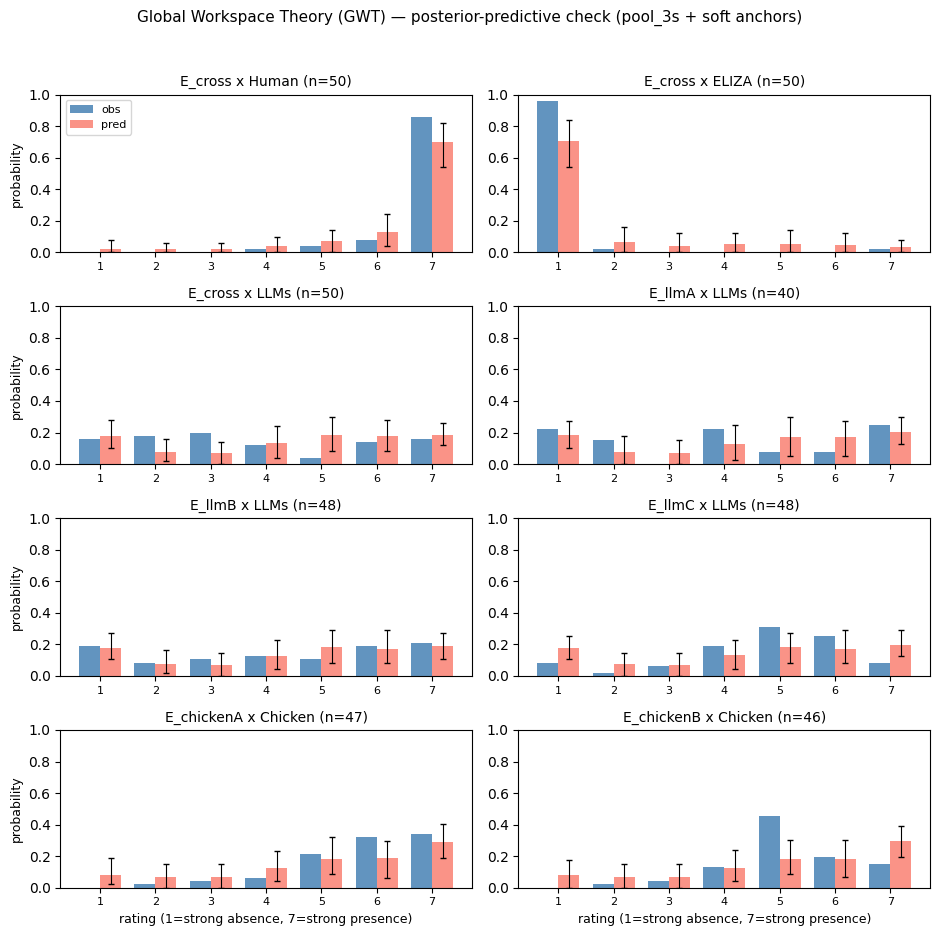

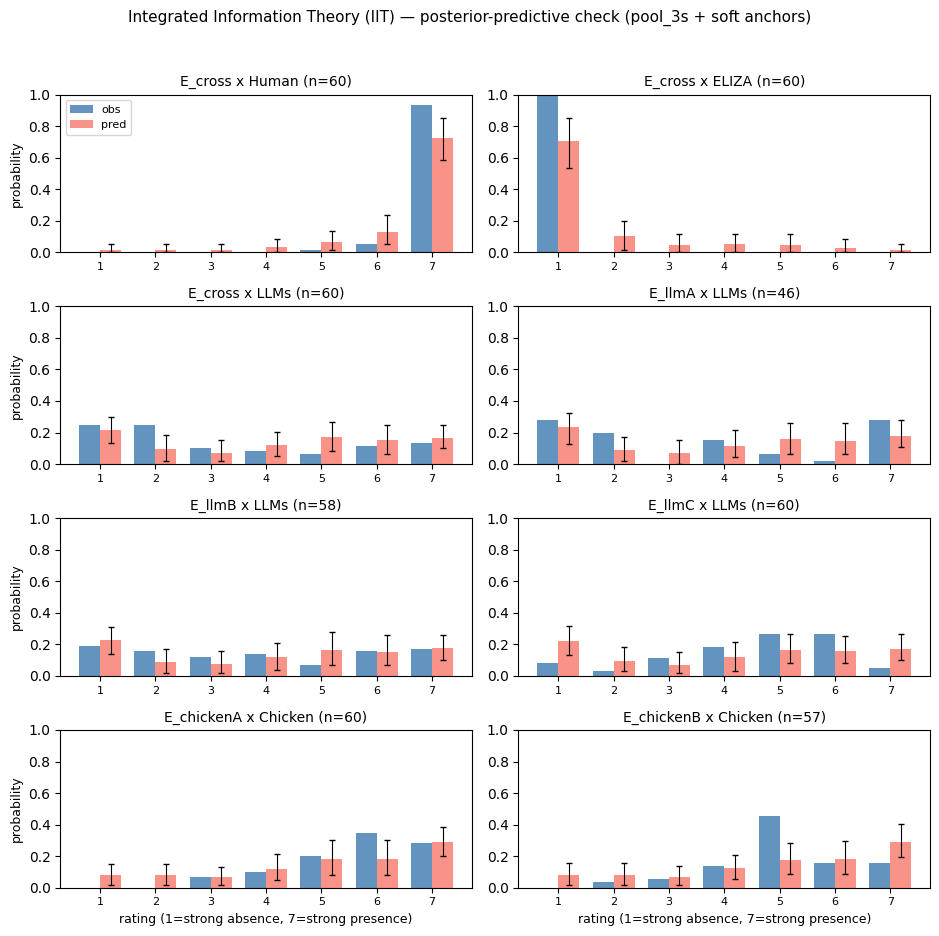

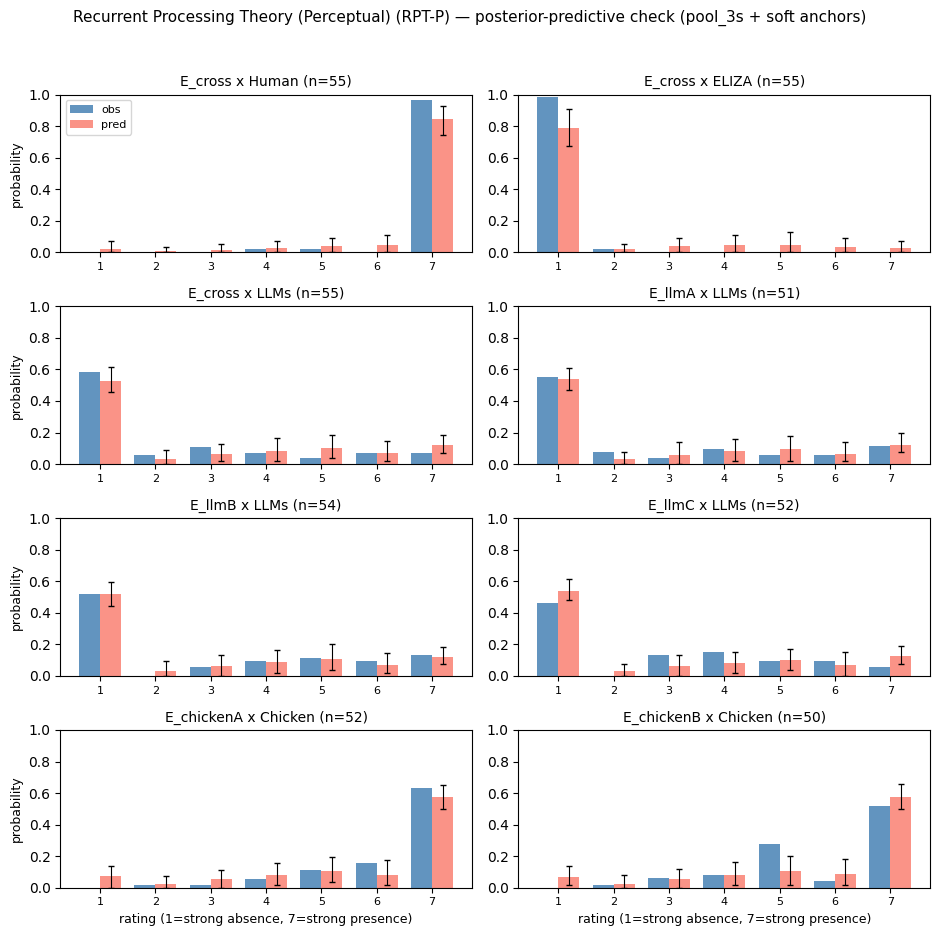

In [4]:
ORDER = [
    ('Human',                  'E_cross'),
    ('ELIZA',                  'E_cross'),
    ('2024 Leading Chat LLMs', 'E_cross'),
    ('2024 Leading Chat LLMs', 'E_llmA'),
    ('2024 Leading Chat LLMs', 'E_llmB'),
    ('2024 Leading Chat LLMs', 'E_llmC'),
    ('Chicken',                'E_chickenA'),
    ('Chicken',                'E_chickenB'),
]
SYS_SHORT = {'Human': 'Human', 'ELIZA': 'ELIZA',
             '2024 Leading Chat LLMs': 'LLMs', 'Chicken': 'Chicken'}

def plot_ppc_grid(fit_entry, title, out_path):
    idata, bld, proc = fit_entry['idata'], fit_entry['bld'], fit_entry['proc']
    ppc = per_expert_system_ppc_multisystem(idata, bld, proc, n_draws=500, seed=42,
                                             indicator_prob_source='pz1')
    cells = []
    for sys_name, anon in ORDER:
        real = REAL_BY_ANON[anon]
        key = (real, sys_name)
        if key in ppc:
            cells.append((anon, sys_name, ppc[key]))

    K = 7; cats = np.arange(K); bin_labels = [str(k + 1) for k in range(K)]; width = 0.38
    nrows, ncols = 4, 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(9.5, 9.5), squeeze=False)
    for idx, (anon, sys_name, r) in enumerate(cells):
        i, j = idx // ncols, idx % ncols
        ax = axes[i, j]
        ax.bar(cats - width/2, r['obs_hist'], width, label='obs', color='steelblue', alpha=0.85)
        ax.bar(cats + width/2, r['pred_hist_mean'], width, label='pred', color='salmon', alpha=0.85)
        ax.errorbar(
            cats + width/2, r['pred_hist_mean'],
            yerr=[np.clip(r['pred_hist_mean'] - r['pred_hist_lo'], 0, None),
                  np.clip(r['pred_hist_hi'] - r['pred_hist_mean'], 0, None)],
            fmt='none', color='black', capsize=2, linewidth=0.8,
        )
        ax.set_xticks(cats); ax.set_xticklabels(bin_labels, fontsize=8)
        ax.set_ylim(0, 1.0)
        ax.set_title(f"{anon} x {SYS_SHORT[sys_name]} (n={r['n_obs']})", fontsize=10)
        if idx == 0: ax.legend(fontsize=8, loc='upper left')
        if j == 0: ax.set_ylabel('probability', fontsize=9)
        if i == nrows - 1: ax.set_xlabel('rating (1=strong absence, 7=strong presence)', fontsize=9)
    fig.suptitle(title, fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(out_path, dpi=140, bbox_inches='tight')
    plt.show()

for short in fits:
    f = fits[short]
    plot_ppc_grid(
        f,
        title=f'{f["stance"]} ({short}) — posterior-predictive check (pool_3s + soft anchors)',
        out_path=f'notebooks/figs/nb20_ppc_{slug(f["stance"])}.png',
    )

## 3 — Notes

- This is exploratory. Reduced sampling (1000 × 4 chains = 4000 draws instead of the usual 8000). Posterior means should be roughly right; HDIs and tail probabilities less reliable than the full GWT fit.
- The `E_cross × Human` and `E_cross × ELIZA` residual pattern is expected to recur across stances — the bottleneck is the rater pool and the shared emission, not the specific stance tree. Checking.
- The `P(C=1 \mid \mathrm{data})` plot is useful for seeing whether different stances put Chicken and LLMs in meaningfully different places. The tree encodes stance-specific theoretical claims (e.g., IIT's Representationality → Information Integration emphasis), so Chicken / LLM posteriors should differ in interpretable ways across stances.